In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("result.csv")
print("Data shape:", df.shape)

Data shape: (553, 17)


In [2]:
# 读取数据
# 需要对比的“帮助策略”列名与展示名
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",  "Goal Recognition"),
    ("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper", "paper"),
    ("steps_with_help_paper2", "paper2")
]

# 基线列名
base_col = "steps_baseline"


# 也顺手打印 baseline 的均值
avg_steps = float(np.nanmean(df[base_col].astype(float)))
print(f"Baseline avg steps: {avg_steps:.2f}")

# 逐个帮助策略与 baseline 对比
for col, label in help_cols:
    print("-" * 60)
    if col not in df.columns:
        print(f"[INFO] {dataset}: '{col}' not found; skip this help variant.")
        continue

    # 向量化清洗
    s  = pd.to_numeric(df[base_col], errors="coerce")
    sh = pd.to_numeric(df[col],       errors="coerce")

    # 过滤缺失
    mask = s.notna() & sh.notna()
    s, sh = s[mask].astype(float), sh[mask].astype(float)

    # 计算差值/比例/成功率
    diff = s - sh
    succ_rate = float((diff > 0).mean()) if len(diff) else 0.0

    # 仅在 s>0 时计算相对比例
    mask_pos = s > 0
    mean_ratio = float(((diff[mask_pos]) / s[mask_pos]).mean()) if mask_pos.any() else 0.0

    mean_diff = float(diff.mean()) if len(diff) else 0.0
    avg_steps_help = float(sh.mean()) if len(sh) else float("nan")

    # 输出结果（英文）
    print(
        f"[{label}]  Δsteps(mean)={mean_diff:.2f},  "
        f"Mean ratio={mean_ratio:.2%},  "
        f"Success(reduced)={succ_rate:.2%},  "
        f"Avg steps (help)={avg_steps_help:.2f}"
    )

Baseline avg steps: 66.74
------------------------------------------------------------
[Greedy]  Δsteps(mean)=13.55,  Mean ratio=8.67%,  Success(reduced)=45.03%,  Avg steps (help)=53.18
------------------------------------------------------------
[Uniform]  Δsteps(mean)=21.30,  Mean ratio=18.00%,  Success(reduced)=49.73%,  Avg steps (help)=45.43
------------------------------------------------------------
[Goal Recognition]  Δsteps(mean)=23.69,  Mean ratio=21.15%,  Success(reduced)=62.03%,  Avg steps (help)=43.05
------------------------------------------------------------
[Upperbound]  Δsteps(mean)=27.39,  Mean ratio=26.92%,  Success(reduced)=81.19%,  Avg steps (help)=39.35
------------------------------------------------------------
[paper]  Δsteps(mean)=13.34,  Mean ratio=8.26%,  Success(reduced)=46.84%,  Avg steps (help)=53.40
------------------------------------------------------------
[paper2]  Δsteps(mean)=11.03,  Mean ratio=6.66%,  Success(reduced)=43.94%,  Avg steps (help)=55.

In [3]:
import ast

# 确保 goals 列转为列表对象
df["goals"] = df["goals"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# 计算每行 goal 的数量
df["num_goals"] = df["goals"].apply(len)
# 按数量统计出现次数
goal_counts = df["num_goals"].value_counts().sort_index()
print("=== Goal count distribution ===")
print(goal_counts)

=== Goal count distribution ===
num_goals
2    112
3    115
4    105
5    114
6    107
Name: count, dtype: int64


In [4]:
# 去掉缺失值（保证两列都能比较）
df = df.dropna(subset=["steps_with_help_uniform", "steps_with_help_gr"])

# 计算差值
df["diff_uniform_gr"] = df["steps_with_help_uniform"] - df["steps_with_help_gr"]
df["abs_diff"] = df["diff_uniform_gr"].abs()


# uniform 更大（baseline 步数更多 → 更差）
uniform_better = df[df["diff_uniform_gr"] < 0].copy()  # uniform 更优（步数少）
gr_better = df[df["diff_uniform_gr"] > 0].copy()       # gr 更优（步数少）

print(f"Uniform higher count: {len(uniform_better)}")
print(f"GR higher count: {len(gr_better)}")

# 分组平均差距（哪一类差得更多）
mean_diff_uniform_better = uniform_better["abs_diff"].mean()
mean_diff_gr_better = gr_better["abs_diff"].mean()

print("\n=== Group-wise average differences ===")
print(f"Average difference (Uniform better cases): {mean_diff_uniform_better:.2f}")
print(f"Average difference (GR better cases): {mean_diff_gr_better:.2f}")


Uniform higher count: 44
GR higher count: 136

=== Group-wise average differences ===
Average difference (Uniform better cases): 6.09
Average difference (GR better cases): 11.68


           Uniform better  GR better
num_goals                           
2                       9         17
3                       6         28
4                      11         30
5                       6         36
6                      12         25


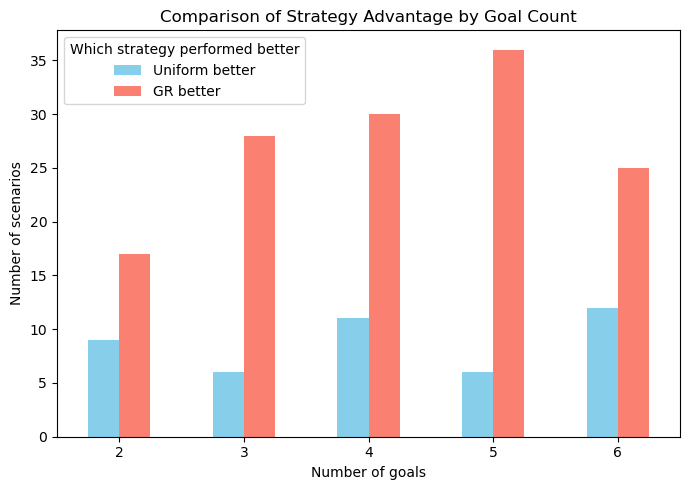

In [5]:
uniform_counts = uniform_better["num_goals"].value_counts().sort_index()
gr_counts = gr_better["num_goals"].value_counts().sort_index()

# 组合成一个 DataFrame 便于对比
compare_df = pd.DataFrame({
    "Uniform better": uniform_counts,
    "GR better": gr_counts
}).fillna(0).astype(int)

print(compare_df)

# === 双柱对比图 ===
compare_df.plot(kind="bar", figsize=(7, 5), color=["skyblue", "salmon"])
plt.title("Comparison of Strategy Advantage by Goal Count")
plt.xlabel("Number of goals")
plt.ylabel("Number of scenarios")
plt.xticks(rotation=0)
plt.legend(title="Which strategy performed better")
plt.tight_layout()
plt.show()

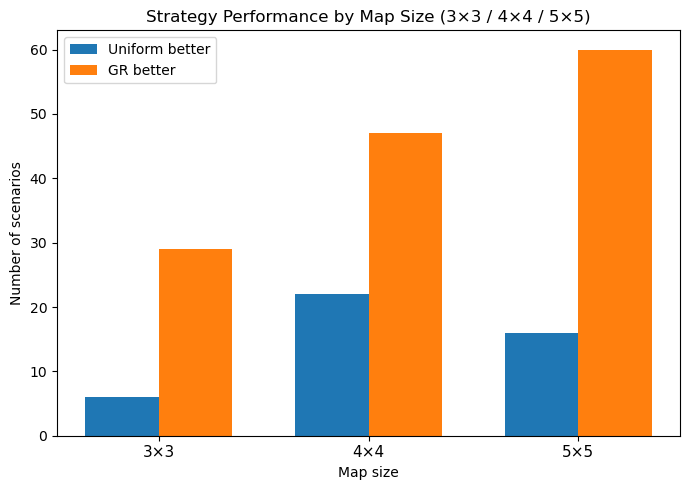

In [6]:
# —— 接着之前的 df 继续 —— #

# 计算地图面积
df["map_area"] = df["num_rows"] * df["num_cols"]

# 按离散面积统计两种策略更优的数量（Uniform 更优=diff<0，GR 更优=diff>0）
compare_map = df.groupby("map_area").agg(
    uniform_better=("diff_uniform_gr", lambda s: (s < 0).sum()),
    gr_better=("diff_uniform_gr",      lambda s: (s > 0).sum()),
)

# 给横轴做成 3×3 / 4×4 / 5×5 这样的标签
labels = [f"{int(np.sqrt(a))}×{int(np.sqrt(a))}" for a in compare_map.index]

# 画双柱图
x = np.arange(len(compare_map))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, compare_map["uniform_better"], width=width, label="Uniform better", color="#1f77b4")
plt.bar(x + width/2, compare_map["gr_better"],      width=width, label="GR better",      color="#ff7f0e")

plt.xticks(x, labels, fontsize=11)
plt.title("Strategy Performance by Map Size (3×3 / 4×4 / 5×5)")
plt.xlabel("Map size")
plt.ylabel("Number of scenarios")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
count_201 = (df["steps_baseline"] == 201).sum()
print(f"Number of rows where steps_baseline unsolveable: {count_201}")

Number of rows where steps_baseline unsolveable: 46


In [8]:
subset = df[df["steps_baseline"] == 201]
# uniform 更大（baseline 步数更多 → 更差）
subset_uniform_better = subset[subset["diff_uniform_gr"] < 0].copy()  # uniform 更优（步数少）
subset_gr_better = subset[subset["diff_uniform_gr"] > 0].copy()       # gr 更优（步数少）

# 分组平均差距（哪一类差得更多）
mean_diff_uniform_better = subset_uniform_better["abs_diff"].mean()
mean_diff_gr_better = subset_gr_better["abs_diff"].mean()

print("\n=== Group-wise average differences ===")
print(f"Average difference (Uniform better cases): {mean_diff_uniform_better:.2f}")
print(f"Average difference (GR better cases): {mean_diff_gr_better:.2f}")


=== Group-wise average differences ===
Average difference (Uniform better cases): 2.00
Average difference (GR better cases): 9.50


           Uniform better  GR better
num_goals                           
2                       0          2
3                       0          2
4                       0          2
5                       0          1
6                       1          3


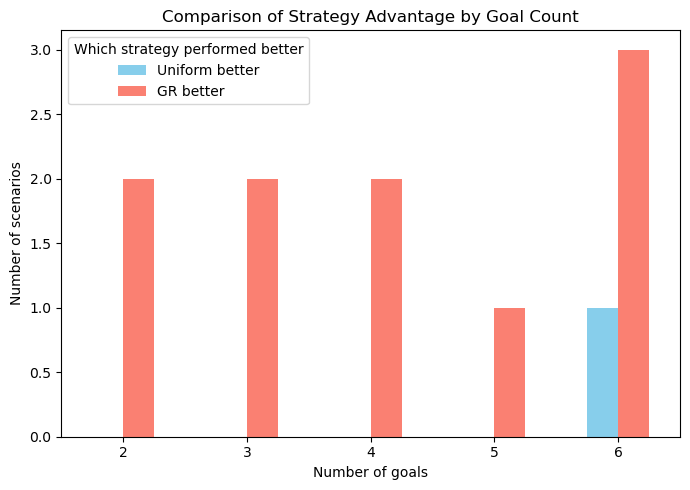

In [9]:
uniform_counts = subset_uniform_better["num_goals"].value_counts().sort_index()
gr_counts = subset_gr_better["num_goals"].value_counts().sort_index()

# 组合成一个 DataFrame 便于对比
compare_df = pd.DataFrame({
    "Uniform better": uniform_counts,
    "GR better": gr_counts
}).fillna(0).astype(int)

print(compare_df)

# === 双柱对比图 ===
compare_df.plot(kind="bar", figsize=(7, 5), color=["skyblue", "salmon"])
plt.title("Comparison of Strategy Advantage by Goal Count")
plt.xlabel("Number of goals")
plt.ylabel("Number of scenarios")
plt.xticks(rotation=0)
plt.legend(title="Which strategy performed better")
plt.tight_layout()
plt.show()